In [1]:
import hyperspy.api as hs
from tifffile import imread, imwrite

In [2]:
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar

In [3]:
import stem_analysis.plot as saplt

In [4]:
import os

In [6]:
from pandas import DataFrame, read_csv

In [8]:
%matplotlib widget

In [9]:
plt.style.use("/Users/nihy/Desktop/stem_analysis/src/stem_analysis/nature.mplstyle")

In [6]:
img = imread('/Users/nihy/Desktop/Working Data/DRX/Zone 211/Shear Corrected/Analysis/object_phase_cropped.tif')
img.shape

(26, 363, 363)

In [7]:
dr = 0.02630 # in nm

findfont: Failed to find font weight normal, now using 0.


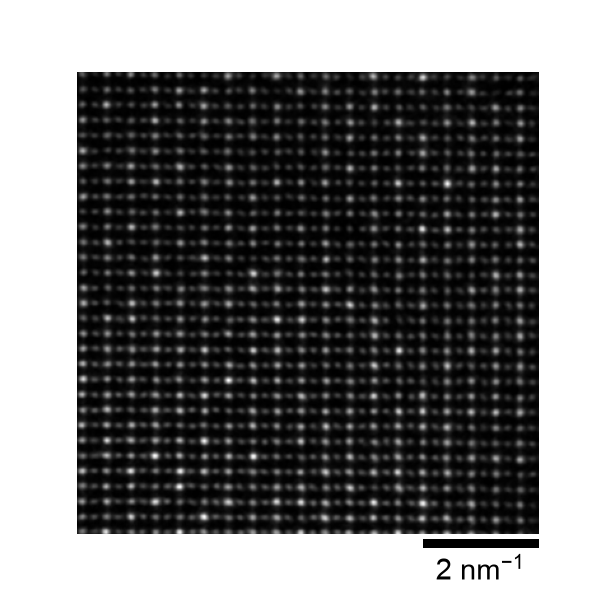

In [8]:
fig = plt.figure(figsize = (2,2))
saplt.PlotImage(fig, img.mean(0), dr, unit='nm', dimension = 'reciprocal-space')

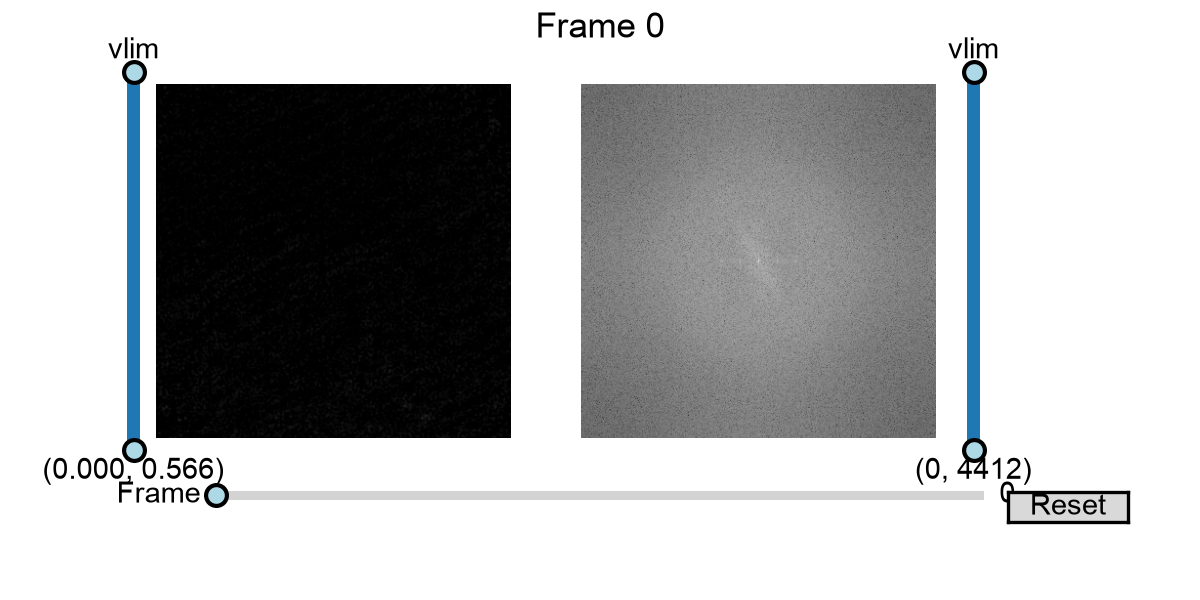

In [9]:
saplt.SliceViewer(img)

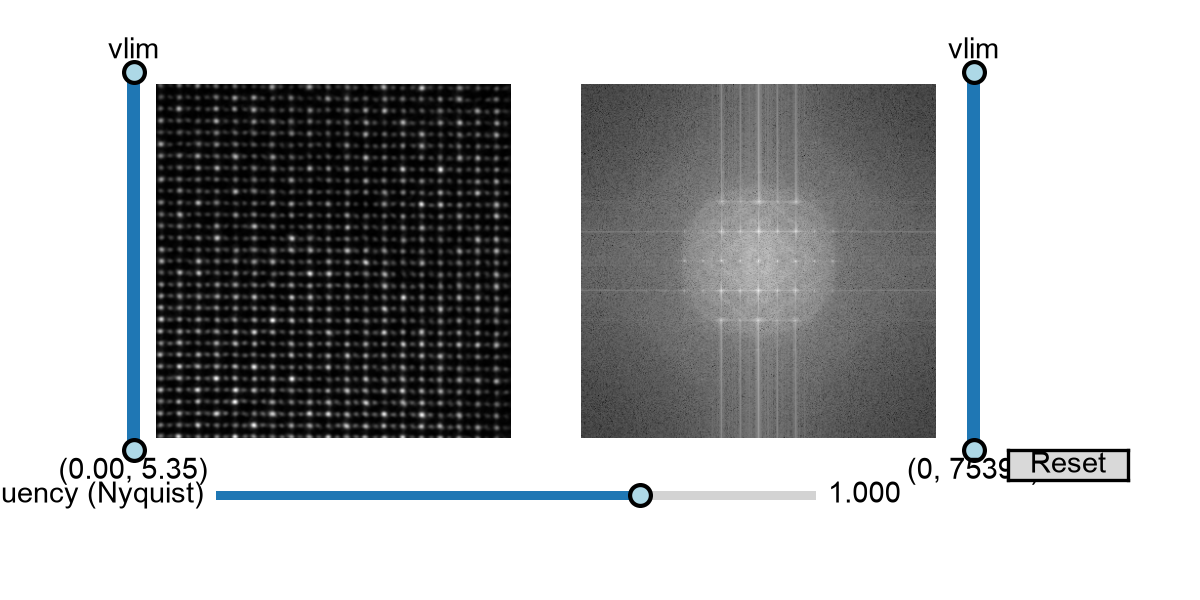

In [11]:
saplt.SoftBandPassFilter(img.sum(0))

In [54]:
img_fft = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(img.sum(0))))
img_ifft = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(img_fft)))

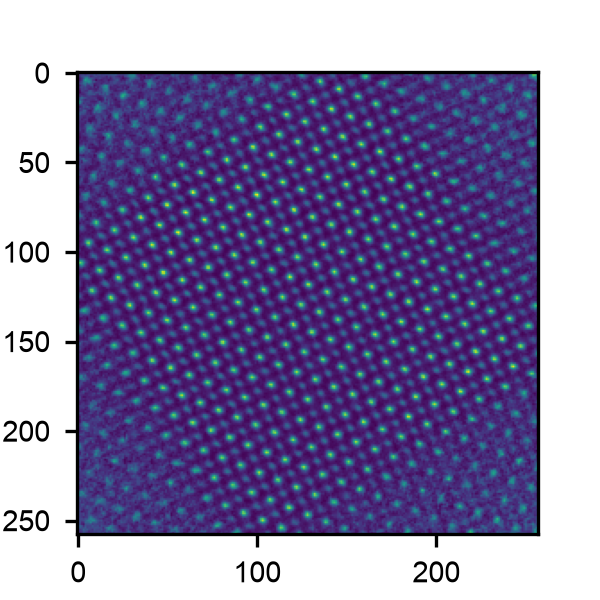

In [55]:
plt.figure(figsize = (2,2))
plt.imshow(img_ifft.real)

In [14]:
import numpy as np

In [37]:
def SoftLowPassFilter(img, sigma_nyquist):
    # Apply a soft band-pass filter based on the frequency slider value
    fft = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(img)))

    fy = np.fft.fftshift(np.fft.fftfreq(fft.shape[0]))/0.5
    fx = np.fft.fftshift(np.fft.fftfreq(fft.shape[1]))/0.5

    fxx, fyy = np.meshgrid(fx, fy)
    fr = np.sqrt(fxx**2 + fyy**2)

    H = np.exp(-0.5*(fr/sigma_nyquist)**2)

    fft_filtered = fft * H
    ifft_filtered = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(fft_filtered)))

    return ifft_filtered

In [38]:
filtered_img = [np.abs(SoftLowPassFilter(frame, 0.05)) for frame in img]

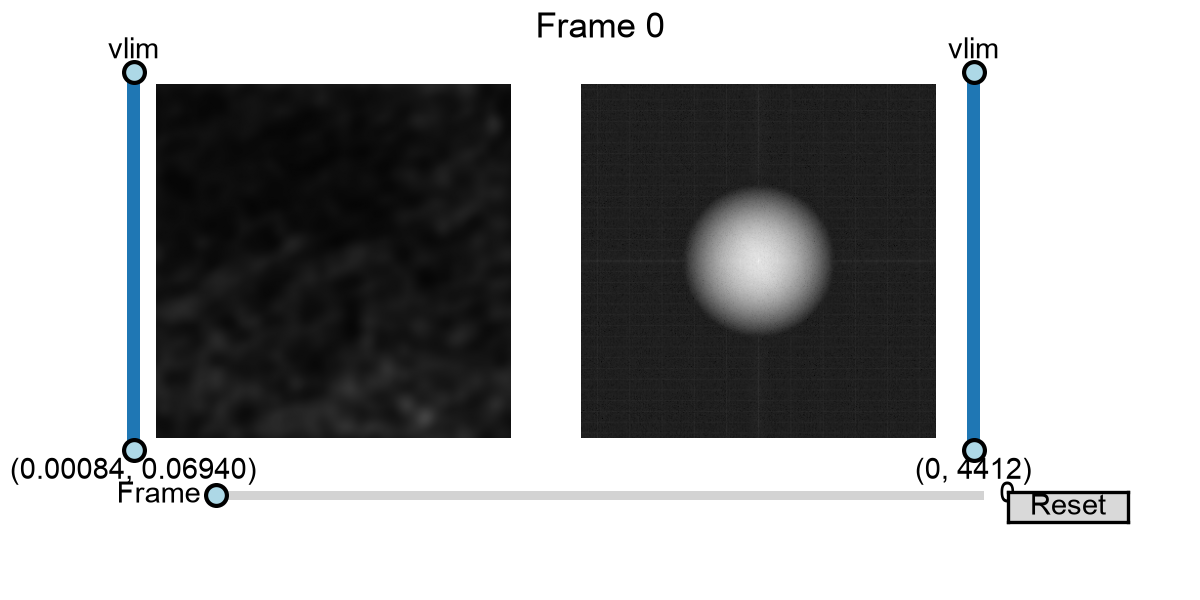

In [39]:
saplt.SliceViewer(np.array(filtered_img))

In [43]:
work_dir = '/Users/nihy/Desktop/Working Data/DRX/Zone 211/Shear Corrected/Analysis/'

In [45]:
imwrite(os.path.join(work_dir, "filtered_img_stack.tif"), np.array(filtered_img).astype('float32'))